<a href="https://colab.research.google.com/github/ccarr-x/CMOR-438-SP-2026/blob/main/examples/Supervised_Learning/gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Gradient Descent Optimization

Gradient Descent is an iterative optimization algorithm used to find the location of the minimum value of a cost function. It works by calculating and searching the path directly opposite to the steepest path(gradient) of the function at the current location.

The components of this model are:
1.  **The Cost Function:** The function of neuron error that we want to minimize.
2.  **Gradient:** The derivative of the cost function, indicating the direction and magnitude of the steepest path.
3.  **Learning Rate:** A hyperparameter that determines the size of the steps taken in the opposite direction of the gradient.

The update rule for a function of one variable is then: `new_cost = current_cost - learning_rate * gradient(current_guess)`

The update rule for a function of several variables is: `new_cost = current_cost - learning_rate * gradient(current_guess)`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

These expressions define two simple quadratic functions that we can test optimization with:

Single Variable: `f(x) = 3x^2`

Multi-Variable(2+):
`f(x) = x^2 - 4x + 5`

In [2]:
# Declaring Cost Function and Gradient for the Single-Var model
def function1(x):
    return 3*x**2
def gradient1(x):
    # Derivative of 3x^2 = 6x
    return 6*x

# Declaring Cost Function and Gradient for the Multi-Var model
def function2(x):
    return x**2 - 4*x + 5
def gradient2(x):
    # Derivative of x^2 - 4x + 5 = 2x - 4
    return 2*x - 4

Here, we will define the `GradientDescentOptimizer` class, which encapsulates the gradient descent algorithm.

In [3]:
class GradientDescent:
    def __init__(self, function, gradient, learning_rate, num_iterations):
        self.function = function
        self.gradient = gradient
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.history = []

    def optimize(self, current_cost):
        self.history = [current_cost]

        for _ in range(self.num_iterations):
            gradient = self.gradient(current_cost)
            current_cost = current_cost - self.learning_rate * gradient
            self.history.append(current_cost)

        return np.array(self.history)


After running the algorithm on our example multi-variable quadratic function, we can see the gradient descent method growing closer to its goal, stopping short 1.0003 units from the true minimum. This is indicates an overestimation that can be lessened by adjusting the learning rate.

In [4]:
# Parameters for Gradient Descent, alpha = array of learning rate values
current_cost = 10.0
learning_rate = 0.2
alpha = [0.1, 0.15, 0.25, 0.3, 0.5]
num_iterations = 20

# Create an instance of the class and run Gradient Descent Algorithm
gdmodel = GradientDescent(function, gradient, learning_rate, num_iterations)
history = gdmodel.optimize(current_cost)
print(history) # Array of all guesses made

# Generate x values for plotting the function
x_values = np.linspace(0, 10, 100)
y_values = function(x_values)

# Plot the function and the gradient descent steps
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='f(x) = x^2 - 4x + 5', color='blue')
plt.scatter(history, function(history), color='red', label='GD Steps', zorder=5)
plt.plot(history, function(history), color='red', linestyle='--', alpha=0.6)

plt.title('Gradient Descent Optimization')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final optimized x: {history[-1]:.4f}")
print(f"Minimum value of f(x): {function(history[-1]):.4f}")

NameError: name 'function' is not defined

### Testing Different Learning Rates (Alpha Values)


Learning Rate: 0.1, Final optimized x: 2.0922, Minimum value of f(x): 1.0085
Learning Rate: 0.15, Final optimized x: 2.0064, Minimum value of f(x): 1.0000
Learning Rate: 0.25, Final optimized x: 2.0000, Minimum value of f(x): 1.0000
Learning Rate: 0.3, Final optimized x: 2.0000, Minimum value of f(x): 1.0000
Learning Rate: 0.5, Final optimized x: 2.0000, Minimum value of f(x): 1.0000
Learning Rate: 0.7, Final optimized x: 2.0000, Minimum value of f(x): 1.0000


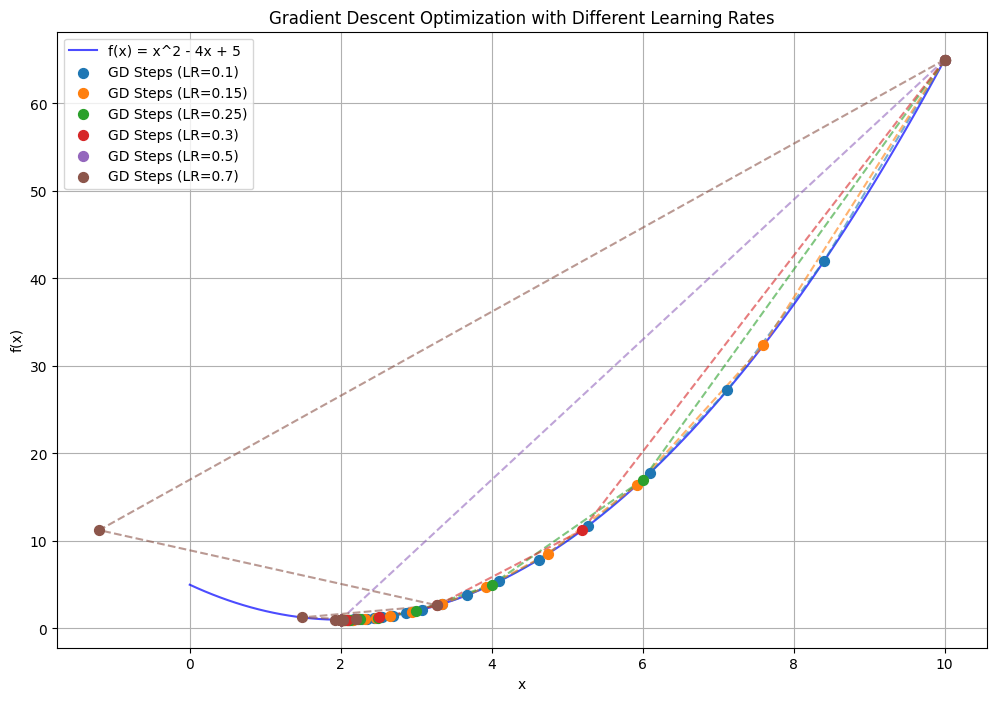

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(x_values, y_values, label='f(x) = x^2 - 4x + 5', color='blue', alpha=0.7)

# Parameters for Gradient Descent, alpha = array of new learning rate values
current_cost = 10.0
alpha = [0.1, 0.15, 0.25, 0.3, 0.5]
num_iterations = 20

# Loop through the different learning rates
for lr in alpha:
    gdmodel_lr = GradientDescent(function, gradient, lr, num_iterations)
    history_lr = gdmodel_lr.optimize(current_cost)
    plt.scatter(history_lr, function(history_lr), label=f'GD Steps (LR={lr})', s=50, zorder=5)
    plt.plot(history_lr, function(history_lr), linestyle='--', alpha=0.6)
    print(f"Learning Rate: {lr}, Final optimized x: {history_lr[-1]:.4f}, Minimum value of f(x): {function(history_lr[-1]):.4f}")

plt.title('Gradient Descent Optimization with Different Learning Rates')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()